<a href="https://colab.research.google.com/github/mosesdorri-gif/Quantitative-market-risk-engine/blob/main/05_stress_testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [65]:
#doing the imports

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt


In [66]:
#data for historical prices

TICKERS = ["SPY", "QQQ", "TLT", "GLD", "XLE"]

WEIGHTS = np.array([0.30, 0.20, 0.20, 0.15, 0.15])
prices = yf.download(
    TICKERS,
    start="2015-01-01",
    end="2026-01-01",
    auto_adjust=True,
    progress=False
)["Close"]

prices = prices.dropna()

prices.head()
PORTFOLIO_VALUE = 100_000

# Check that weights sum to 100%
assert np.isclose(WEIGHTS.sum(), 1.0)

# Dollar allocation
portfolio_allocation = pd.Series(
    WEIGHTS * PORTFOLIO_VALUE,
    index=TICKERS,
    name="Allocation"
)

portfolio_allocation

,Allocation
SPY,30000.0
QQQ,20000.0
TLT,20000.0
GLD,15000.0
XLE,15000.0


In [67]:
#log returns

log_returns = np.log(prices / prices.shift(1)).dropna()

log_returns.head()

Ticker,GLD,QQQ,SPY,TLT,XLE
Date,,,,,
2015-01-05,0.014965,-0.014778,-0.018225,0.015587,-0.042248
2015-01-06,0.011334,-0.013498,-0.009464,0.017857,-0.014800
2015-01-07,-0.005909,0.012808,0.012384,-0.001977,0.002128
2015-01-08,-0.004217,0.018959,0.017589,-0.013331,0.022201
2015-01-09,0.011321,-0.006605,-0.008046,0.010893,-0.007956


In [68]:
#definition for the historical scenarios

historical_scenarios = {
    "COVID Crash": ("2020-02-19", "2020-03-23"),
    "2022 Rate Shock": ("2022-01-03", "2022-06-16"),
    "2022 Market Selloff": ("2022-01-03", "2022-10-14"),
    "2020 Recovery": ("2020-03-23", "2020-08-18"),
}

In [69]:
#getting the historical scenario returns

scenario_returns = {}

for scenario, (start_date, end_date) in historical_scenarios.items():

    scenario_data = prices.loc[start_date:end_date]

    if len(scenario_data) < 2:
        print(f"Insufficient data for {scenario}")
        continue

    start_prices = scenario_data.iloc[0]
    end_prices = scenario_data.iloc[-1]

    returns = (end_prices / start_prices) - 1

    scenario_returns[scenario] = returns

scenario_returns_df = pd.DataFrame(scenario_returns).T

scenario_returns_df

Ticker,GLD,QQQ,SPY,TLT,XLE
COVID Crash,-0.036168,-0.279166,-0.337173,0.142343,-0.560667
2022 Rate Shock,0.025902,-0.323527,-0.230100,-0.219776,0.371612
2022 Market Selloff,-0.091190,-0.347654,-0.242698,-0.305882,0.447927
2020 Recovery,0.286261,0.633541,0.525590,-0.001190,0.610978


In [70]:
#portfolio stress loss

portfolio_scenario_returns = scenario_returns_df @ WEIGHTS

stress_results = pd.DataFrame({
    "Portfolio Return": portfolio_scenario_returns,
    "Portfolio P&L": portfolio_scenario_returns * PORTFOLIO_VALUE
})

stress_results["Loss"] = -stress_results["Portfolio P&L"]

stress_results.sort_values("Portfolio Return")
stress_results

,Portfolio Return,Portfolio P&L,Loss
COVID Crash,-0.196867,-19686.676941,19686.676941
2022 Rate Shock,-0.080180,-8017.955043,8017.955043
2022 Market Selloff,-0.124121,-12412.067944,12412.067944
2020 Recovery,0.409173,40917.261947,-40917.261947


In [71]:
# P&L Attribution on the asset level

scenario_pnl = scenario_returns_df.copy()

for ticker in TICKERS:
    scenario_pnl[ticker] = (
        scenario_returns_df[ticker]
        * portfolio_allocation[ticker]
    )

scenario_pnl

Ticker,GLD,QQQ,SPY,TLT,XLE
COVID Crash,-542.524917,-5583.315294,-10115.177163,2846.856560,-8410.002791
2022 Rate Shock,388.522595,-6470.543719,-6902.985689,-4395.524556,5574.177362
2022 Market Selloff,-1367.849397,-6953.085727,-7280.939127,-6117.642422,6718.907812
2020 Recovery,4293.915456,12670.811007,15767.702792,-23.792785,9164.662755


In [72]:
scenario_pnl["Total P&L"] = scenario_pnl.sum(axis=1)

scenario_pnl

Ticker,GLD,QQQ,SPY,TLT,XLE,Total P&L
COVID Crash,-542.524917,-5583.315294,-10115.177163,2846.856560,-8410.002791,-21804.163606
2022 Rate Shock,388.522595,-6470.543719,-6902.985689,-4395.524556,5574.177362,-11806.354006
2022 Market Selloff,-1367.849397,-6953.085727,-7280.939127,-6117.642422,6718.907812,-15000.608861
2020 Recovery,4293.915456,12670.811007,15767.702792,-23.792785,9164.662755,41873.299226


In [73]:
#hypothetical stress scenarios

hypothetical_scenarios = {

    "Equity Crash": {
        "SPY": -0.20,
        "QQQ": -0.25,
        "TLT":  0.05,
        "GLD":  0.05,
        "XLE": -0.25
    },

    "Severe Equity Crash": {
        "SPY": -0.30,
        "QQQ": -0.40,
        "TLT":  0.10,
        "GLD":  0.10,
        "XLE": -0.40
    },

    "Interest Rate Shock": {
        "SPY": -0.08,
        "QQQ": -0.12,
        "TLT": -0.15,
        "GLD": -0.05,
        "XLE":  0.02
    },

    "Commodity Shock": {
        "SPY": -0.05,
        "QQQ": -0.05,
        "TLT":  0.02,
        "GLD": -0.10,
        "XLE": -0.20
    },

    "Inflation Shock": {
        "SPY": -0.10,
        "QQQ": -0.15,
        "TLT": -0.12,
        "GLD":  0.08,
        "XLE":  0.15
    },

    "Broad Market Selloff": {
        "SPY": -0.15,
        "QQQ": -0.20,
        "TLT": -0.05,
        "GLD": -0.05,
        "XLE": -0.20
    }
}

In [74]:
#hypothetical scenario DF

hypothetical_returns = pd.DataFrame(
    hypothetical_scenarios
).T[TICKERS]

hypothetical_returns

,SPY,QQQ,TLT,GLD,XLE
Equity Crash,-0.20,-0.25,0.05,0.05,-0.25
Severe Equity Crash,-0.30,-0.40,0.10,0.10,-0.40
Interest Rate Shock,-0.08,-0.12,-0.15,-0.05,0.02
Commodity Shock,-0.05,-0.05,0.02,-0.10,-0.20
Inflation Shock,-0.10,-0.15,-0.12,0.08,0.15
Broad Market Selloff,-0.15,-0.20,-0.05,-0.05,-0.20


In [75]:
#hypothetical portfolio stress results

hypothetical_portfolio_returns = (
    hypothetical_returns @ WEIGHTS
)

hypothetical_results = pd.DataFrame({
    "Portfolio Return": hypothetical_portfolio_returns,
    "Portfolio P&L": (
        hypothetical_portfolio_returns
        * PORTFOLIO_VALUE
    )
})

hypothetical_results["Loss"] = (
    -hypothetical_results["Portfolio P&L"]
)

hypothetical_results.sort_values("Portfolio Return")

,Portfolio Return,Portfolio P&L,Loss
Severe Equity Crash,-0.1950,-19500.0,19500.0
Broad Market Selloff,-0.1325,-13250.0,13250.0
Equity Crash,-0.1300,-13000.0,13000.0
Interest Rate Shock,-0.0825,-8250.0,8250.0
Commodity Shock,-0.0660,-6600.0,6600.0
Inflation Shock,-0.0495,-4950.0,4950.0


In [76]:
#hypothetical _pnl attribution

hypothetical_pnl = hypothetical_returns.copy()

for ticker in TICKERS:
    hypothetical_pnl[ticker] = (
        hypothetical_returns[ticker]
        * portfolio_allocation[ticker]
    )

hypothetical_pnl["Total P&L"] = hypothetical_pnl.sum(axis=1)

hypothetical_pnl

,SPY,QQQ,TLT,GLD,XLE,Total P&L
Equity Crash,-6000.0,-5000.0,1000.0,750.0,-3750.0,-13000.0
Severe Equity Crash,-9000.0,-8000.0,2000.0,1500.0,-6000.0,-19500.0
Interest Rate Shock,-2400.0,-2400.0,-3000.0,-750.0,300.0,-8250.0
Commodity Shock,-1500.0,-1000.0,400.0,-1500.0,-3000.0,-6600.0
Inflation Shock,-3000.0,-3000.0,-2400.0,1200.0,2250.0,-4950.0
Broad Market Selloff,-4500.0,-4000.0,-1000.0,-750.0,-3000.0,-13250.0


In [77]:
#identifying the worst scenario

worst_historical = stress_results["Portfolio Return"].idxmin()
worst_historical_return = stress_results.loc[
    worst_historical,
    "Portfolio Return"
]

worst_hypothetical = hypothetical_results[
    "Portfolio Return"
].idxmin()

worst_hypothetical_return = hypothetical_results.loc[
    worst_hypothetical,
    "Portfolio Return"
]

print("Worst Historical Scenario:")
print(worst_historical)
print(f"Portfolio Return: {worst_historical_return:.2%}")
print()

print("Worst Hypothetical Scenario:")
print(worst_hypothetical)
print(f"Portfolio Return: {worst_hypothetical_return:.2%}")

Worst Historical Scenario:
COVID Crash
Portfolio Return: -19.69%

Worst Hypothetical Scenario:
Severe Equity Crash
Portfolio Return: -19.50%


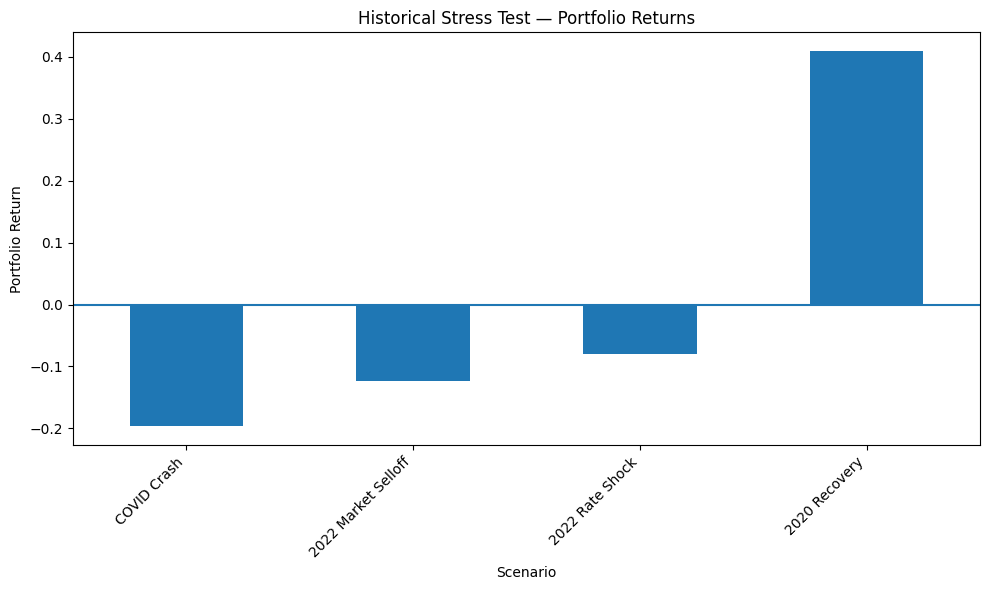

In [78]:
#historical stress results

historical_plot = (
    stress_results["Portfolio Return"]
    .sort_values()
)

plt.figure(figsize=(10, 6))

historical_plot.plot(kind="bar")

plt.title("Historical Stress Test — Portfolio Returns")
plt.ylabel("Portfolio Return")
plt.xlabel("Scenario")
plt.xticks(rotation=45, ha="right")

plt.axhline(0)

plt.tight_layout()
plt.show()

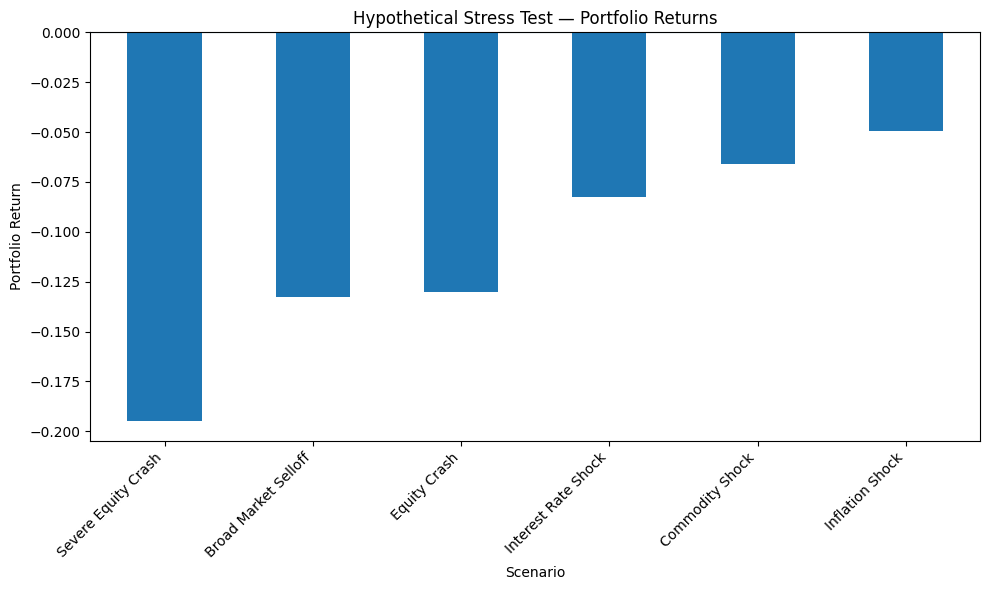

In [79]:
#hypothetical stress results

hypothetical_plot = (
    hypothetical_results["Portfolio Return"]
    .sort_values()
)

plt.figure(figsize=(10, 6))

hypothetical_plot.plot(kind="bar")

plt.title("Hypothetical Stress Test — Portfolio Returns")
plt.ylabel("Portfolio Return")
plt.xlabel("Scenario")
plt.xticks(rotation=45, ha="right")

plt.axhline(0)

plt.tight_layout()
plt.show()

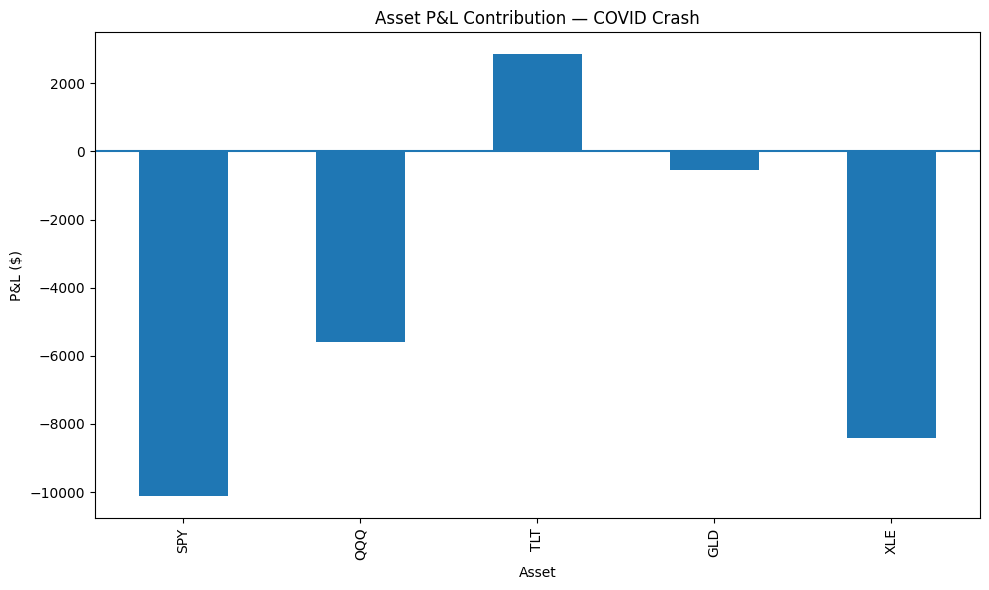

In [80]:
#Worst Historical Scenario Attribution

worst_case_pnl = scenario_pnl.loc[worst_historical, TICKERS]

plt.figure(figsize=(10, 6))

worst_case_pnl.plot(kind="bar")

plt.title(
    f"Asset P&L Contribution — {worst_historical}"
)

plt.ylabel("P&L ($)")
plt.xlabel("Asset")

plt.axhline(0)

plt.tight_layout()
plt.show()

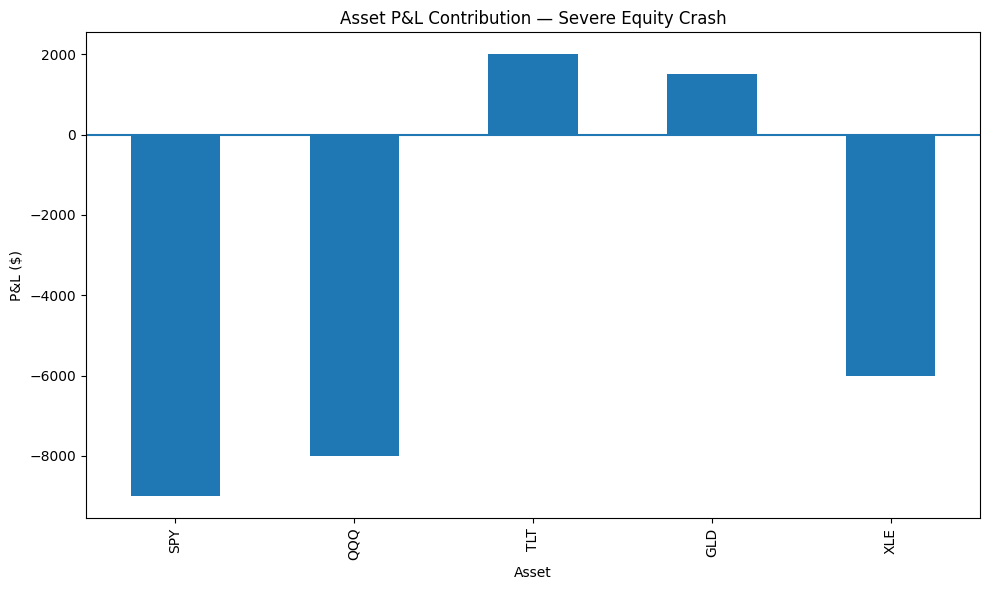

In [81]:
#worst hypothetical scenario attribution

worst_hypothetical_pnl = hypothetical_pnl.loc[
    worst_hypothetical,
    TICKERS
]

plt.figure(figsize=(10, 6))

worst_hypothetical_pnl.plot(kind="bar")

plt.title(
    f"Asset P&L Contribution — {worst_hypothetical}"
)

plt.ylabel("P&L ($)")
plt.xlabel("Asset")

plt.axhline(0)

plt.tight_layout()
plt.show()

In [82]:
#combined stress test summary

historical_summary = pd.DataFrame({
    "Scenario Type": "Historical",
    "Portfolio Return": stress_results["Portfolio Return"],
    "Portfolio P&L": stress_results["Portfolio P&L"],
    "Loss": stress_results["Loss"]
})

hypothetical_summary = pd.DataFrame({
    "Scenario Type": "Hypothetical",
    "Portfolio Return": hypothetical_results["Portfolio Return"],
    "Portfolio P&L": hypothetical_results["Portfolio P&L"],
    "Loss": hypothetical_results["Loss"]
})

combined_stress_results = pd.concat([
    historical_summary,
    hypothetical_summary
])

combined_stress_results = (
    combined_stress_results
    .sort_values("Portfolio Return")
)

combined_stress_results

,Scenario Type,Portfolio Return,Portfolio P&L,Loss
COVID Crash,Historical,-0.196867,-19686.676941,19686.676941
Severe Equity Crash,Hypothetical,-0.195000,-19500.000000,19500.000000
Broad Market Selloff,Hypothetical,-0.132500,-13250.000000,13250.000000
Equity Crash,Hypothetical,-0.130000,-13000.000000,13000.000000
2022 Market Selloff,Historical,-0.124121,-12412.067944,12412.067944
Interest Rate Shock,Hypothetical,-0.082500,-8250.000000,8250.000000
2022 Rate Shock,Historical,-0.080180,-8017.955043,8017.955043
Commodity Shock,Hypothetical,-0.066000,-6600.000000,6600.000000
Inflation Shock,Hypothetical,-0.049500,-4950.000000,4950.000000
2020 Recovery,Historical,0.409173,40917.261947,-40917.261947


In [83]:
#formatted stress test results

formatted_results = combined_stress_results.copy()

formatted_results["Portfolio Return"] = (
    formatted_results["Portfolio Return"]
    .map(lambda x: f"{x:.2%}")
)

formatted_results["Portfolio P&L"] = (
    formatted_results["Portfolio P&L"]
    .map(lambda x: f"${x:,.2f}")
)

formatted_results["Loss"] = (
    formatted_results["Loss"]
    .map(lambda x: f"${x:,.2f}")
)

formatted_results

,Scenario Type,Portfolio Return,Portfolio P&L,Loss
COVID Crash,Historical,-19.69%,"$-19,686.68","$19,686.68"
Severe Equity Crash,Hypothetical,-19.50%,"$-19,500.00","$19,500.00"
Broad Market Selloff,Hypothetical,-13.25%,"$-13,250.00","$13,250.00"
Equity Crash,Hypothetical,-13.00%,"$-13,000.00","$13,000.00"
2022 Market Selloff,Historical,-12.41%,"$-12,412.07","$12,412.07"
Interest Rate Shock,Hypothetical,-8.25%,"$-8,250.00","$8,250.00"
2022 Rate Shock,Historical,-8.02%,"$-8,017.96","$8,017.96"
Commodity Shock,Hypothetical,-6.60%,"$-6,600.00","$6,600.00"
Inflation Shock,Hypothetical,-4.95%,"$-4,950.00","$4,950.00"
2020 Recovery,Historical,40.92%,"$40,917.26","$-40,917.26"
